# Real Estate Analysis
Project inspired by the DataWars challenge: [Real Estate Analysis](https://app.datawars.io/project/214e265c-029f-4940-9a35-f43a9e0c56cc?page=1).

In [1]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

## Baseline Submission

### Load training data

In [2]:
train_df = pd.read_csv('train.csv')
train_df.head()

,Title,Description,location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area,Price_USD,Amount_USD
0,3 BHK Ready to Occupy Flat for sale in Runwal ...,Carefully laid out in the prime location of Gh...,mumbai,806 sqft,Ready to Move,Upper Basement out of 15,Resale,Semi-Furnished,East,Main Road,Runwal Orchard Residency,2,3,1 Covered,Freehold,NaN,NaN,NaN,199.0 USD,271084.0
1,2 BHK Ready to Occupy Flat for sale in Shilale...,Up for immediate sale is a 2 BHK apartment in ...,ahmedabad,900 sqft,Ready to Move,1 out of 4,Resale,Unfurnished,NaN,Main Road,Shilalekh Apartments,2,2,NaN,Freehold,NaN,NaN,NaN,70.0 USD,63012.0
2,2 BHK Ready to Occupy Flat for sale Koramangala,This magnificent 2 BHK Flat is available for s...,bangalore,1000 sqft,Ready to Move,Ground out of 7,New Property,Unfurnished,West,Garden/Park,NaN,2,1,1 Covered,Freehold,NaN,NaN,NaN,127.0 USD,186747.0
3,4 BHK Ready to Occupy Flat for sale in Hiranan...,Have a look at this immaculate 4 BHK flat for ...,thane,1520 sqft,Ready to Move,14 out of 27,Resale,Unfurnished,East,Garden/Park,Hiranandani Meadows,4,1,2 Covered,Freehold,NaN,NaN,NaN,144.0 USD,289157.0
4,3 BHK Ready to Occupy Flat for sale Jagatpur,Have a look at this immaculate 3 BHK flat for ...,ahmedabad,NaN,Ready to Move,3 out of 9,Resale,Unfurnished,NaN,NaN,NaN,3,NaN,NaN,NaN,1773 sqft,NaN,NaN,50.0 USD,90361.0


### Load testing data

In [3]:
test_df = pd.read_csv('test_inputs.csv')
test_df.head()

,Title,Description,location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area,Price_USD
0,3 BHK Ready to Occupy Flat for sale in Bhartiy...,"Thanisandra Main Road, Bangalore has an appeal...",bangalore,1415 sqft,Ready to Move,32 out of 32,Resale,Semi-Furnished,East,NaN,NaN,3,3,NaN,NaN,NaN,NaN,NaN,157.0 USD
1,3 BHK Ready to Occupy Flat for sale in DS Max ...,This ready to move-in 3 BHK flat is available ...,bangalore,NaN,Ready to Move,5 out of 5,Resale,Semi-Furnished,NaN,NaN,NaN,4,NaN,NaN,NaN,3350 sqft,NaN,NaN,46.0 USD
2,2 BHK Ready to Occupy Flat for sale in Vijay E...,2 BHK flat available for sale in Thane in the ...,thane,800 sqft,Ready to Move,5 out of 14,Resale,Semi-Furnished,East,Garden/Park,Vijay Enclave,2,2,NaN,Co-operative Society,NaN,NaN,NaN,NaN
3,2 BHK Ready to Occupy Flat for sale in Charany...,Have a look at this immaculate 2 BHK flat for ...,bangalore,NaN,Ready to Move,1 out of 3,Resale,Semi-Furnished,NaN,NaN,NaN,2,NaN,NaN,NaN,1100 sqft,NaN,NaN,87.0 USD
4,2 BHK Ready to Occupy Flat for sale Kalyan East,"Kalyan East, Thane has an appealing 2 BHK flat...",thane,NaN,Ready to Move,3 out of 4,Resale,Semi-Furnished,NaN,NaN,NaN,4,NaN,NaN,NaN,1100 sqft,NaN,NaN,48.0 USD


We start with a simple baseline: predict the average training price for every test row. This is not very accurate, but it establishes a useful reference point.

In [4]:
train_df['Amount_USD'].mean()

np.float64(135075.36967741934)

The baseline prediction value is:

In [5]:
baseline = train_df['Amount_USD'].mean()

In [6]:
baseline

np.float64(135075.36967741934)

Create a constant prediction list for all test rows (6344 rows):

In [7]:
y_pred = [baseline] * 6344

The baseline predictions are ready.

You can run validation/check activity now.

## Feature Engineering and Modeling

---

### Working cells

In [8]:
test_df.isna().sum()

Title             0
Description     160
location          1
Carpet Area    3392
Status           14
Floor           243
Transaction       4
Furnishing      102
facing         2974
overlooking    3262
Society        4064
Bathroom         16
Balcony        2396
Car Parking    3890
Ownership      2761
Super Area     2993
Dimensions     6344
Plot Area      6344
Price_USD       292
dtype: int64

In [9]:
train_df.nunique()

Title          4473
Description    6247
location          6
Carpet Area    1106
Status            1
Floor           645
Transaction       4
Furnishing        3
facing            8
overlooking      13
Society        1626
Bathroom         11
Balcony           9
Car Parking      53
Ownership         4
Super Area     1079
Dimensions        0
Plot Area         0
Price_USD       438
Amount_USD      758
dtype: int64

In [10]:
for col in train_df.columns:
    unique_values = train_df[col].unique()
    if len(unique_values) < 60:
        print(f"{col}: {unique_values}")
    else:
        print(f"{col} has more than 60 uniques")
    print()

train_df[["Carpet Area", "Super Area", "Price_USD", "Amount_USD"]]
train_df["Floor"]

Title has more than 60 uniques

Description has more than 60 uniques

location: <StringArray>
['mumbai', 'ahmedabad', 'bangalore', 'thane', 'navi-mumbai', 'nagpur']
Length: 6, dtype: str

Carpet Area has more than 60 uniques

Status: <StringArray>
['Ready to Move', nan]
Length: 2, dtype: str

Floor has more than 60 uniques

Transaction: <StringArray>
['Resale', 'New Property', nan, 'Other', 'Rent/Lease']
Length: 5, dtype: str

Furnishing: <StringArray>
['Semi-Furnished', 'Unfurnished', 'Furnished', nan]
Length: 4, dtype: str

facing: <StringArray>
[        'East',            nan,         'West', 'North - West',
        'North', 'North - East',        'South',  'South -West',
 'South - East']
Length: 9, dtype: str

overlooking: <StringArray>
[                   'Main Road',                  'Garden/Park',
                            nan, 'Garden/Park, Pool, Main Road',
            'Garden/Park, Pool',       'Garden/Park, Main Road',
 'Main Road, Garden/Park, Pool', 'Pool, Garden/Park, M

0        Upper Basement out of 15
1                      1 out of 4
2                 Ground out of 7
3                    14 out of 27
4                      3 out of 9
                   ...           
19024             Ground out of 4
19025                  1 out of 4
19026                12 out of 29
19027                 5 out of 19
19028                  2 out of 4
Name: Floor, Length: 19029, dtype: str

In [ ]:
dropping = ["Title", "Description", "Status", "Dimensions", "Plot Area", "Society"]
df = train_df.drop(columns=dropping) 
test_df = test_df.drop(columns=dropping)

KeyError: "['Title', 'Description', 'Status', 'Dimensions', 'Plot Area', 'Society'] not found in axis"

In [14]:
df

,location,Carpet Area,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Car Parking,Ownership,Super Area,Price_USD,Amount_USD
0,mumbai,806 sqft,Upper Basement out of 15,Resale,Semi-Furnished,East,Main Road,2,3,1 Covered,Freehold,NaN,199.0 USD,271084.000000
1,ahmedabad,900 sqft,1 out of 4,Resale,Unfurnished,NaN,Main Road,2,2,NaN,Freehold,NaN,70.0 USD,63012.000000
2,bangalore,1000 sqft,Ground out of 7,New Property,Unfurnished,West,Garden/Park,2,1,1 Covered,Freehold,NaN,127.0 USD,186747.000000
3,thane,1520 sqft,14 out of 27,Resale,Unfurnished,East,Garden/Park,4,1,2 Covered,Freehold,NaN,144.0 USD,289157.000000
4,ahmedabad,NaN,3 out of 9,Resale,Unfurnished,NaN,NaN,3,NaN,NaN,NaN,1773 sqft,50.0 USD,90361.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19024,bangalore,NaN,Ground out of 4,Resale,NaN,NaN,NaN,2,3,NaN,NaN,NaN,NaN,135075.369677
19025,ahmedabad,NaN,1 out of 4,Resale,Semi-Furnished,North - East,Garden/Park,2,NaN,1 Open,Freehold,1170 sqft,46.0 USD,54217.000000
19026,thane,575 sqft,12 out of 29,Resale,Unfurnished,North - East,"Garden/Park, Pool, Main Road",2,2,1 Covered,Co-operative Society,NaN,125.0 USD,93976.000000
19027,bangalore,NaN,5 out of 19,Resale,Semi-Furnished,NaN,NaN,3,NaN,NaN,NaN,1874 sqft,115.0 USD,216867.000000


In [15]:
def clean_parking(value):
    if pd.isna(value):
        return 0

    nums = re.findall(r"\d+", str(value))
    if nums:
        count = int(nums[0])
        return count if count < 10 else 1
    return 0


df["parking_count"] = df["Car Parking"].apply(clean_parking)
test_df["parking_count"] = test_df["Car Parking"].apply(clean_parking)


def convert_to_sqft(area_string):
    if pd.isna(area_string):
        return np.nan

    area_string = str(area_string).lower()
    match = re.search(r"[\d.]+", area_string)
    if not match:
        return np.nan

    value = float(match.group())

    if "sqm" in area_string or "sq m" in area_string or "meters" in area_string:
        return value * 10.7639
    elif "sqyrd" in area_string or "sqyd" in area_string or "sq yrd" in area_string:
        return value * 9.0
    elif "sqft" in area_string or "sq ft" in area_string:
        return value
    else:
        return value


df["Carpet Area"] = df["Carpet Area"].apply(convert_to_sqft)
df["Super Area"] = df["Super Area"].apply(convert_to_sqft)
test_df["Carpet Area"] = test_df["Carpet Area"].apply(convert_to_sqft)
test_df["Super Area"] = test_df["Super Area"].apply(convert_to_sqft)


def estimate_missing_areas(row):
    carpet = row["Carpet Area"]
    super_area = row["Super Area"]

    ratio = 0.70

    if pd.isna(carpet) and pd.notna(super_area):
        carpet = super_area * ratio
    elif pd.isna(super_area) and pd.notna(carpet):
        super_area = carpet / ratio

    return pd.Series([carpet, super_area]).round()


df[["Carpet Area", "Super Area"]] = df.apply(estimate_missing_areas, axis=1)
test_df[["Carpet Area", "Super Area"]] = test_df.apply(estimate_missing_areas, axis=1)

calculated_price = df["Amount_USD"] / df["Super Area"]

df["Price_USD"] = df["Price_USD"].astype(str).str.replace(" USD", "", regex=False)
df["Price_USD"] = pd.to_numeric(df["Price_USD"], errors="coerce")

test_df["Price_USD"] = test_df["Price_USD"].astype(str).str.replace(
    " USD", "", regex=False
)
test_df["Price_USD"] = pd.to_numeric(test_df["Price_USD"], errors="coerce")

df["Price_USD"] = df["Price_USD"].fillna(calculated_price)
df["Price_USD"] = df["Price_USD"].round()


city_medians = df.groupby("location")["Price_USD"].median()
test_df["Price_USD"] = test_df["Price_USD"].fillna(test_df["location"].map(city_medians))
test_df["Price_USD"] = test_df["Price_USD"].fillna(df["Price_USD"].median())

overall_median = df["Price_USD"].median()
test_df["Price_USD"] = test_df["Price_USD"].fillna(overall_median)

df["Furnishing"] = df["Furnishing"].fillna("Unfurnished")
test_df["Furnishing"] = test_df["Furnishing"].fillna("Unfurnished")

df["facing"] = df.groupby("location")["facing"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "East")
)
test_df["facing"] = test_df.groupby("location")["facing"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "East")
)

In [16]:
df['overlooking'] = df['overlooking'].fillna('Nothing')
test_df['overlooking'] = test_df['overlooking'].fillna('Nothing')

df['Bathroom'] = df['Bathroom'].replace('> 10', 11)
test_df['Bathroom'] = test_df['Bathroom'].replace('> 10', 11)
df['Bathroom'] = pd.to_numeric(df['Bathroom'], errors='coerce')
test_df['Bathroom'] = pd.to_numeric(test_df['Bathroom'], errors='coerce')

df['Balcony'] = df['Balcony'].replace('> 10', 11)
test_df['Balcony'] = test_df['Balcony'].replace('> 10', 11)
df['Balcony'] = df['Balcony'].fillna(0)
test_df['Balcony'] = test_df['Balcony'].fillna(0)

bins = [0, 500, 1000, 1500, 2000, 3000, 5000, np.inf]
df['area_bracket'] = pd.cut(df['Super Area'], bins=bins)
test_df['area_bracket'] = pd.cut(test_df['Super Area'], bins=bins)

df['Bathroom'] = df.groupby('area_bracket', observed=True)['Bathroom'].transform(
    lambda x: x.fillna(x.median())
)
test_df['Bathroom'] = test_df.groupby('area_bracket', observed=True)['Bathroom'].transform(
    lambda x: x.fillna(x.median())
)

df.drop(columns=['area_bracket'], inplace=True)
test_df.drop(columns=['area_bracket'], inplace=True)
df['Bathroom'] = df['Bathroom'].fillna(1).round().astype(int)
test_df['Bathroom'] = test_df['Bathroom'].fillna(1).round().astype(int)

df.dropna(subset=['Carpet Area', 'Super Area', 'Price_USD'], how='all', inplace=True)
test_df['Super Area'] = test_df['Super Area'].fillna(df['Super Area'].median())
test_df['Price_USD'] = test_df['Price_USD'].fillna(df['Price_USD'].median())

In [17]:
floor_split = df["Floor"].str.split(" out of ", expand=True)
test_floor_split = test_df["Floor"].str.split(" out of ", expand=True)

df["Floor_Level"] = floor_split[0]
df["Total_Floors"] = floor_split[1]
test_df["Floor_Level"] = test_floor_split[0]
test_df["Total_Floors"] = test_floor_split[1]

floor_mapping = {
    "Ground": "0",
    "Upper Basement": "-1",
    "Basement": "-1",
    "Lower Basement": "-2",
}

df["Floor_Level"] = df["Floor_Level"].replace(floor_mapping)
test_df["Floor_Level"] = test_df["Floor_Level"].replace(floor_mapping)

df["Floor_Level"] = pd.to_numeric(df["Floor_Level"], errors="coerce")
test_df["Floor_Level"] = pd.to_numeric(test_df["Floor_Level"], errors="coerce")
df["Total_Floors"] = pd.to_numeric(df["Total_Floors"], errors="coerce")
test_df["Total_Floors"] = pd.to_numeric(test_df["Total_Floors"], errors="coerce")

df.drop(columns=["Floor"], inplace=True)
test_df.drop(columns=["Floor"], inplace=True)

df["Floor_Ratio"] = df["Floor_Level"] / df["Total_Floors"]
test_df["Floor_Ratio"] = df["Floor_Level"] / df["Total_Floors"]

train_floor_medians = df.groupby("location")["Floor_Level"].median()
train_total_floors_medians = df.groupby("location")["Total_Floors"].median()

test_df["Floor_Level"] = test_df["Floor_Level"].fillna(
    test_df["location"].map(train_floor_medians)
)
test_df["Total_Floors"] = test_df["Total_Floors"].fillna(
    test_df["location"].map(train_total_floors_medians)
)

test_df["Floor_Level"] = test_df["Floor_Level"].fillna(df["Floor_Level"].median())
test_df["Total_Floors"] = test_df["Total_Floors"].fillna(df["Total_Floors"].median())

test_df["Floor_Ratio"] = test_df["Floor_Level"] / test_df["Total_Floors"]
test_df["Floor_Ratio"] = test_df["Floor_Ratio"].clip(lower=0)

df = pd.get_dummies(df, columns=["location"], drop_first=True, dtype=int)
test_df = pd.get_dummies(test_df, columns=["location"], drop_first=True, dtype=int)

df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

In [ ]:
df = pd.get_dummies(
    df,
    columns=["Transaction", "Furnishing", "facing", "overlooking", "Ownership"],
    drop_first=True,
    dtype=int,
 )
test_df = pd.get_dummies(
    test_df,
    columns=["Transaction", "Furnishing", "facing", "overlooking", "Ownership"],
    drop_first=True,
    dtype=int,
 )


df["Parking_Spots"] = df["Car Parking"].str.extract(r"(\d+)").astype(float)
test_df["Parking_Spots"] = test_df["Car Parking"].str.extract(r"(\d+)").astype(float)

df["Parking_Spots"] = df["Parking_Spots"].fillna(0)
test_df["Parking_Spots"] = test_df["Parking_Spots"].fillna(0)

df.loc[df["Parking_Spots"] > 5, "Parking_Spots"] = 1
test_df.loc[test_df["Parking_Spots"] > 5, "Parking_Spots"] = 1

df["Is_Covered"] = df["Car Parking"].str.contains(
    "Covered", case=False, na=False
).astype(int)
test_df["Is_Covered"] = test_df["Car Parking"].str.contains(
    "Covered", case=False, na=False
).astype(int)

df.drop(columns=["Car Parking"], inplace=True)
test_df.drop(columns=["Car Parking"], inplace=True)

df["Price_USD"] = df["Price_USD"].astype(str)
test_df["Price_USD"] = test_df["Price_USD"].astype(str)

df["Price_USD"] = df["Price_USD"].str.replace(" USD", "", regex=False).str.strip()
test_df["Price_USD"] = test_df["Price_USD"].str.replace(
    " USD", "", regex=False
).str.strip()

df["Price_USD"] = pd.to_numeric(df["Price_USD"], errors="coerce")
test_df["Price_USD"] = pd.to_numeric(test_df["Price_USD"], errors="coerce")

df["Price_USD"] = df["Price_USD"].round(2)
test_df["Price_USD"] = test_df["Price_USD"].round(2)

R-Squared Score: 0.893
Mean Absolute Error: $6,279.73


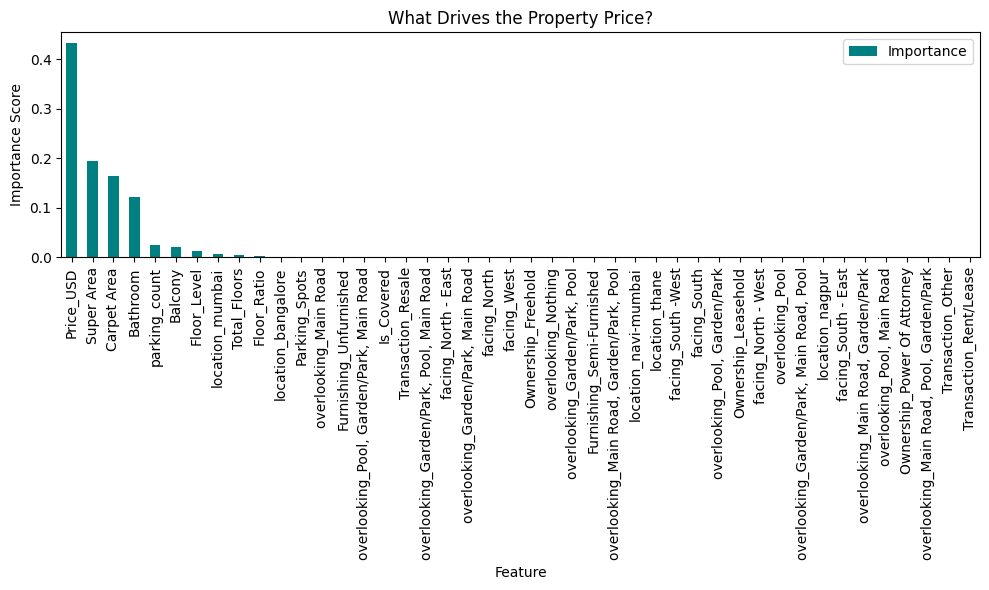

In [19]:
X = df.drop(columns=['Amount_USD']) 
y = df['Amount_USD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)

print(f"R-Squared Score: {r2_score(y_test, predictions):.3f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, predictions):,.2f}")

importance_scores = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

feature_importance_df.plot(kind='bar', x='Feature', y='Importance', figsize=(10, 6), color='teal')
plt.title('What Drives the Property Price?')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
# Debugging the test data alignment issue:
# 1. What columns does the model expect (X) that are missing from your test data?
missing_in_test = set(X.columns) - set(test_df.columns)
print(f"Columns missing in test data: {missing_in_test}")

# 2. What extra columns are in your test data that the model has never seen before?
extra_in_test = set(test_df.columns) - set(X.columns)
print(f"Extra columns in test data: {extra_in_test}")

threshold = 0.001

# 2. Extract the names of the columns that score below the threshold
# (Assuming you still have the 'feature_importance_df' from the earlier step)
noise_columns = feature_importance_df[feature_importance_df['Importance'] < threshold]['Feature'].tolist()

print(f"Identifying {len(noise_columns)} noise columns to drop")

# 3. Drop the noise from your training features
X_clean = X.drop(columns=noise_columns)

test_df_aligned = test_df.reindex(columns=X_clean.columns, fill_value=0)
print(f"Do the columns match perfectly now? {X_clean.columns.equals(test_df_aligned.columns)}")

Columns missing in test data: {'Transaction_Rent/Lease', 'overlooking_Garden/Park, Main Road, Pool', 'overlooking_Main Road, Pool, Garden/Park'}
Extra columns in test data: {'overlooking_Pool, Main Road, Garden/Park'}
Identifying 30 noise columns to drop
Do the columns match perfectly now? True


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)

print(f"R-Squared Score: {r2_score(y_test, predictions):.3f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, predictions):,.2f}")

y_pred = rf_model.predict(test_df_aligned)

y_pred

R-Squared Score: 0.891
Mean Absolute Error: $6,382.12


array([373494.        , 156627.        , 134859.54683226, ...,
       289157.        ,  84337.        ,  48927.83      ], shape=(6344,))